In [1]:
import os
import sys
import glob
import numpy as np
import  scipy.optimize as op
import matplotlib.pyplot as plt
import urllib.request
from astropy.io import fits as fits
from astropy.table import Table
import pandas as pd
import urllib.request
import requests
import astropy.units as u
import astropy
from astropy.coordinates import SkyCoord
from pathlib import Path
from numpy import savetxt
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
from dustmaps.sfd import SFDQuery
import astropy.cosmology.units as cu
from astropy.coordinates import match_coordinates_sky
import io

## SDSS galaxies

/home/hollman/DataHII/gal_info_dr7_v5_2.fit.gz already exist


(array([2.63440e+04, 1.88535e+05, 1.42359e+05, 1.52329e+05, 1.39796e+05,
        1.14497e+05, 8.54860e+04, 6.70230e+04, 1.04170e+04, 3.30000e+01]),
 array([-16.67872238,  -6.58381319,   3.51109624,  13.60600567,
         23.70091438,  33.79582214,  43.89073181,  53.98564148,
         64.08055115,  74.17546082,  84.27037048]),
 <BarContainer object of 10 artists>)

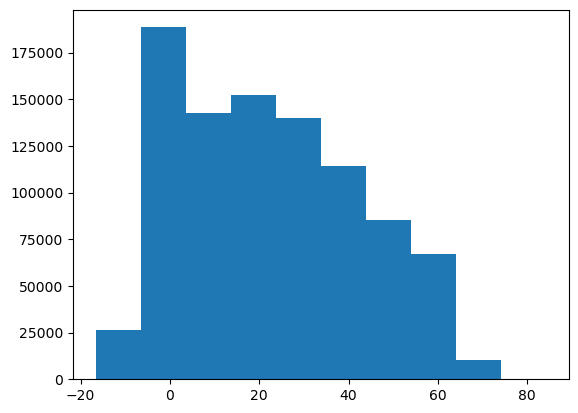

In [16]:
home = os.path.expanduser("~") + '/'
DATA_URL="http://das.sdss.org/spectro/ss_tar_26/"
file="gal_info_dr7_v5_2.fit.gz"
local_file = os.path.join(home + "DataHII/",file)

if not os.path.exists(local_file):
        print("downloading DR7 quasar dataset from %s to %s"
              % (DATA_URL+file, local_file ))
        tmp = urllib.request.urlretrieve(DATA_URL+local_file, local_file)
        print ("Downloaded file"+local_file)
else:
    print("%s already exist"%(local_file))

catalog=Table.read(local_file)
w=((catalog['RA']!=catalog['DEC']) & (catalog['RA']>0) & ((catalog['DEC']>=-90) | (catalog['DEC']<=90)) & (catalog['Z']>=0) & ( catalog['Z'] != float('nan') ) & ( catalog['DEC'] != float('nan') ) & ( catalog['RA'] != float('nan') ))
reduced_cat=catalog[w]
#reduced_cat
plt.hist(reduced_cat['DEC'])

In [17]:
NED = pd.read_csv('NED_Chavez2012.csv', sep=",", header=0)
NED.columns
NED['Redshift (z)'][127] = 0.009486
NED

/tmp/ipykernel_10729/832320834.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  NED['Redshift (z)'][127] = 0.009486
/tmp/ipykernel_10729/832320834.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

,No.,Object Name,RA,Dec,Object Type,Redshift (z)
0,1,UM 199,1.737614,0.857181,G,0.073682
1,2,UM 282,12.947112,0.161124,G,0.037556
2,3,UM 336,23.436174,0.953078,G,0.019236
3,4,MRK 0627,131.643397,36.438978,G,0.010634
4,5,SBS 0934+546,144.556301,54.473618,G,0.102102
...,...,...,...,...,...,...
123,124,WISEA J101136.07+263027.5,152.900317,26.507660,G,0.054666
124,125,WISEA J162152.58+151855.9,245.469098,15.315537,G,0.034341
125,126,WISEA J090506.84+223834.7,136.278600,22.642759,G,0.125548
126,127,WISEA J094000.50+203122.7,145.002109,20.522973,G,0.044799


In [18]:
SIMBAD = pd.read_csv('SIMBAD_Chavez2012.csv', sep=";", header=0)
SIMBAD.columns

Index([' # ', ' obj tags ', 'obj count', '    raw id    ',
       '            identifier             ', 'typ',
       '      coord1 (FK5,J2000/2000)      ', '  redshift  '],
      dtype='object')

In [19]:
data_coor = SIMBAD['      coord1 (FK5,J2000/2000)      ']

ra = np.array([float(str(a).split()[0]) for a in data_coor])
dec = np.array([float(str(a).split()[1]) for a in data_coor])

SIMBAD['ra'] = ra
SIMBAD['dec'] = dec

SIMBAD

,#,obj tags,obj count,raw id,identifier,typ,"coord1 (FK5,J2000/2000)",redshift,ra,dec
0,1,d,3,J000657+005125,SHOC 2,Sy1,001.7374419936384 +00.8573176472766,0.07370,1.737442,0.857318
1,2,d,3,J001647-104742,LEDA 973666,G,004.199012 -10.795065,0.02324,4.199012,-10.795065
2,3,d,3,J002339-094848,6dFGS gJ002339.6-094848,Sy1,005.915047 -09.813533,0.05305,5.915047,-9.813533
3,4,d,3,J002425+140410,LEDA 101427,H2G,006.1081153099142 +14.0696497224747,0.01423,6.108115,14.069650
4,5,d,3,J003218+150014,SHOC 22,H2G,008.0776246735898 +15.0039207329153,0.01795,8.077625,15.003921
...,...,...,...,...,...,...,...,...,...,...
132,133,d,3,J230117+135230,SDSS J230117.64+135230.2,G,345.323545 +13.875071,0.02456,345.323545,13.875071
133,134,d,3,J230123+133314,[ITS2007] 52263-742-179,H2G,345.348307 +13.554096,0.03029,345.348307,13.554096
134,135,d,3,J230703+011311,SHOC 595,Sy1,346.7656830052835 +01.2197848644810,0.12577,346.765683,1.219785
135,136,d,3,J231442+010621,[VV2003c] J231442.1+010620,Sy1,348.675646 +01.105846,0.03420,348.675646,1.105846


In [20]:
### Mathc between NED and SIMBAD



NED_astro = Table.from_pandas(NED)
#NED_astro = NED_astro[NED_astro['Object Name']=='WISEA J192757.99-413431.8']
SIMBAD_astro = Table.from_pandas(SIMBAD)
SIMBAD_astro = SIMBAD_astro[SIMBAD_astro['  redshift  ']>=0]


In [79]:

ra1 = np.array(SIMBAD_astro['ra'])
dec1 = np.array(SIMBAD_astro['dec'])
D1 = np.array(SIMBAD_astro['  redshift  '])


ra2 = np.array(NED_astro['RA'])
dec2 = np.array(NED_astro['Dec'])
D2 = np.array(NED_astro['Redshift (z)'])




SIMBAD_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree,
                      distance = D1 * u.kpc)


NED_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree,
                    distance = D2 * u.kpc)



idx, d2d, d3d = NED_cat.match_to_catalog_sky(SIMBAD_cat)

In [87]:
len(idx)
#idx

new_SIMBAD = SIMBAD_astro[idx]
len(np.unique(new_SIMBAD['            identifier             ']))

128

In [92]:
ra1 = np.array(reduced_cat['RA'])
dec1 = np.array(reduced_cat['DEC'])
D1 = np.array(reduced_cat['Z'])



ra2 = np.array(new_SIMBAD['ra'])
dec2 = np.array(new_SIMBAD['dec'])
D2 = np.array(new_SIMBAD['  redshift  '])




SDSS_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree,
                      distance = D1 * u.kpc)


SIMBADmod_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree,
                    distance = D2 * u.kpc)



idx, d2d, d3d = SIMBADmod_cat.match_to_catalog_sky(SDSS_cat)





In [93]:
len(idx)

128

In [94]:
FOLDER = ['1d_23','1d_25','1d_26']
PLATE = '0266'
URL = "https://data.sdss.org/sas/dr7/das2/spectro/"

In [95]:
def check_link(path): # Function that takes care of seeing if the file exists on the web or not
    r = requests.head(path)
    status = r.status_code == requests.codes.ok
    if (status == True):
        return True
    else:
        return False

In [96]:
download_list = []
for n in range(len(idx)):
#for n in range(20):
    plateid = str(reduced_cat['PLATEID'][idx[n]])
    mjd = str(reduced_cat['MJD'][idx[n]])
    fiberid = str(reduced_cat['FIBERID'][idx[n]])
    

    if (len(plateid)<4) or (len(mjd)<5) or (len(fiberid)<3):
        if (len(plateid)<4):
            for x in range(4-len(plateid)):
                plateid = '0' + plateid
        if (len(mjd)<5):
            for y in range(5-len(mjd)):
                mjd = '0' + mjd
        if (len(fiberid)<3):
            for z in range(3-len(fiberid)):
                fiberid = '0' + fiberid
    #print(plateid,mjd,fiberid)

    pre_link = URL + FOLDER[0] + '/' + plateid +"/1d/spSpec" + '-' + mjd + '-' + plateid + '-' + fiberid + '.fit'

    if check_link(pre_link)==False:
        pre_link = URL + FOLDER[1] + '/' + plateid +"/1d/spSpec" + '-' + mjd + '-' + plateid + '-' + fiberid + '.fit'
        if check_link(pre_link)==False:
            pre_link = URL + FOLDER[2] + '/' + plateid +"/1d/spSpec" + '-' + mjd + '-' + plateid + '-' + fiberid + '.fit'
            if check_link(pre_link)==False:
                download_list.append('Not Found')
            else:
                download_list.append(pre_link)
        else:
            download_list.append(pre_link)
    else:
        download_list.append(pre_link)

download_list


['https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0388/1d/spSpec-51793-0388-457.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0691/1d/spSpec-52199-0691-636.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0400/1d/spSpec-51820-0400-441.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0934/1d/spSpec-52672-0934-369.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0556/1d/spSpec-51991-0556-224.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0284/1d/spSpec-51662-0284-277.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0341/1d/spSpec-51690-0341-606.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_25/2689/1d/spSpec-54149-2689-190.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0384/1d/spSpec-51821-0384-281.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_25/2426/1d/spSpec-53795-2426-015.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/1216/1d/spSpec-52709-1216-619.fit',
 'https://data.sdss.org/sas/dr7/das2/spectr

In [99]:
idx

array([ 57041, 205064,  64753, 307155, 144180,  10595,  38532, 889363,
        54582, 817872, 401848, 687793,  35824, 729084, 830892, 677087,
       676733, 536800, 688441, 919379, 915909, 889445, 339551, 889443,
       275290, 237819,  71492, 141170, 113090, 187769, 620110, 309988,
       292141, 230078,  80321, 545424, 337865, 580635, 605940, 118700,
       111211,  77688,   1341,   5447, 188486, 190901, 196271, 182235,
       181708, 106391,  53728, 193512,  87203, 196233,  99384,  99845,
       100696, 101146, 104029,  93279,  95952, 107195, 109263,  26405,
       181046, 181131,  53386, 181779, 152687, 153845, 194461, 221618,
       350886, 338615, 387298, 392325, 413067, 431182, 112525, 150398,
       198880, 121129, 121404,  50495, 151492, 147622, 146622, 146670,
       224241, 224657, 224641, 223761, 278138, 277103, 328086, 416662,
       532702, 531653, 539917, 603896, 609962, 603887, 666060, 661354,
       605570, 665430, 671418, 667766, 676096, 739280,  10194, 120227,
      

In [102]:
len(np.unique(idx))

128

In [100]:
reduced_cat[57041]

PLATEID,MJD,FIBERID,PHOTOID,RA,DEC,PLUG_MAG,PRIMTARGET,SECTARGET,TARGETTYPE,SPECTROTYPE,SUBCLASS,Z,Z_ERR,Z_WARNING,V_DISP,V_DISP_ERR,SN_MEDIAN,E_BV_SFD,ZTWEAK,ZTWEAK_ERR,SPECTRO_MAG,KCOR_MAG,KCOR_MODEL_MAG,RELEASE
int16,int32,int16,int16[5],float32,float32,float32[5],int16,int16,bytes19,bytes6,bytes21,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32[3],float32[3],float32[5],bytes12
388,51793,457,125 .. 89,1.7376115,0.8572106,19.8516 .. 19.1226,4,0,QSO,GALAXY,STARBURST,0.07368165,4.4130834e-06,0,0.0,21.396189,7.8278704,0.03703327,0.0,0.0,18.522682 .. 18.230062,18.452908 .. 18.825542,0.0 .. 0.0,dr123


In [101]:
fits_folder = '/DataHII/HIIGs/FITS/'

if (os.path.exists(home + fits_folder) == True):
    print('Folder for spec set saving already created \n')
else:
    print(f'Folder for spec set saveing created ({home+fits_folder}) \n')
    os.mkdir(home+fits_folder)

for f in range(len(download_list)):
    print(f"({f+1}/{len(download_list)}) Downloading {download_list[f][-25:]} ...")
    direc = home + fits_folder + download_list[f][-25:]
    DOWNLOAD = urllib.request.urlretrieve(download_list[f], direc)

Folder for spec set saving already created 

(1/128) Downloading spSpec-51793-0388-457.fit ...
(2/128) Downloading spSpec-52199-0691-636.fit ...
(3/128) Downloading spSpec-51820-0400-441.fit ...
(4/128) Downloading spSpec-52672-0934-369.fit ...
(5/128) Downloading spSpec-51991-0556-224.fit ...
(6/128) Downloading spSpec-51662-0284-277.fit ...
(7/128) Downloading spSpec-51690-0341-606.fit ...
(8/128) Downloading spSpec-54149-2689-190.fit ...
(9/128) Downloading spSpec-51821-0384-281.fit ...
(10/128) Downloading spSpec-53795-2426-015.fit ...
(11/128) Downloading spSpec-52709-1216-619.fit ...
(12/128) Downloading spSpec-53463-1981-438.fit ...
(13/128) Downloading spSpec-51997-0337-097.fit ...
(14/128) Downloading spSpec-53534-2112-557.fit ...
(15/128) Downloading spSpec-53857-2489-123.fit ...
(16/128) Downloading spSpec-53431-1947-448.fit ...
(17/128) Downloading spSpec-53432-1946-609.fit ...
(18/128) Downloading spSpec-52992-1594-563.fit ...
(19/128) Downloading spSpec-53442-1983-308.fit

In [21]:
Spec = fits.open(home + fits_folder + 'spSpec-52263-0742-161.fit')

In [22]:
def spec_plotter(name,RL=4000,LL=7000):
    local_dirspc="/home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/"
    spc = os.path.join(local_dirspc,name)  
    file = fits.open(spc)
    DATA = file[0].data
    zz = file[0].header['Z']
    RA = file[0].header['RA']
    DEC = file[0].header['DEC']
    c = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs')
    c.galactic
    sfd = SFDQuery()
    ebv01 = sfd(c.galactic)
    flux = DATA[0]
    wav00 = file[0].header['COEFF0']
    wavdiff = file[0].header['COEFF1']
    waveair = 10**(wav00 + wavdiff*np.arange(len(flux)))
    waveobs = waveair/(1.0+2.735182E-4+131.4182/(waveair)**2 +2.76249E8/(waveair)**4)
    file.close()
    wave = waveobs/(1.0+zz)
    fluxUnred = pyasl.unred(wave, flux, ebv=ebv01, R_V=3.1)
    flux_final = fluxUnred*(1.0+zz)**3
    wave_in = int(wave[2])             #initial wavelength
    wave_fin = int(wave[len(wave)-2])  #final wavelength
    wave_new = np.arange(wave_in, wave_fin, 1)
    flux_interpolate = interp1d(wave, flux_final, kind='quadratic')
    flux_starlight = flux_interpolate(wave_new)
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.bottom'] = True
    plt.figure(figsize=(20,8),dpi=70)
    plt.plot(wave,flux_final,label = 'Flux',lw=0.7, color ='#1C448E')
    plt.ylabel(r"$F_{\lambda}\ \left[ 10^{-17}\ {\rm erg\ s}^{-1}\ {\rm cm}^{-2}\ \AA^{-1} \right]$", style = 'oblique', family = 'serif', size = 25)
    plt.xlabel('Wavelength [$\AA$]', style = 'oblique', family = 'serif', size = 25)
    plt.yticks(fontsize = 15)
    plt.xticks(fontsize = 15)
    plot_lim = [RL,LL]
    plt.xlim(plot_lim)
    plt.ylim(0,max(flux)+15)
    plt.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
    txt_prop = {'style' : 'oblique', 'family' : 'serif', 'size' :15}       
    plt.legend(title = f'z = {round((zz),3)}', prop = txt_prop, loc= 'upper right')
    plt.show()


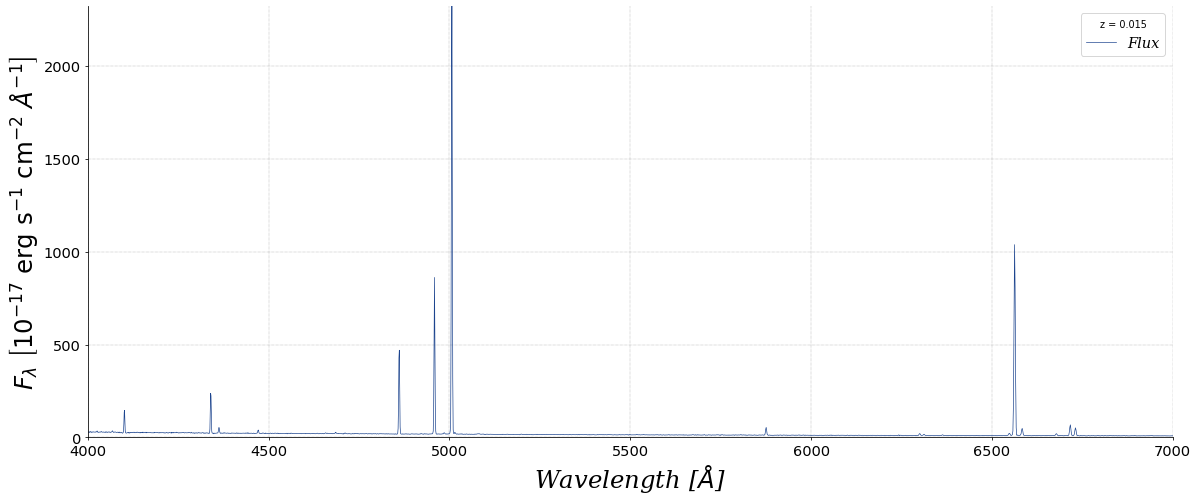

In [24]:
spec_plotter('spSpec-52992-1594-563.fit')

## GEHRs

In [3]:
#CALIFA

home = os.path.expanduser("~") + '/'


file="CALIFA_Mother_Sample.dat"
local_file = os.path.join(home + "DataHII/",file)


local_file

'/home/hollman/DataHII/CALIFA_Mother_Sample.dat'

In [4]:
CALIFA = pd.read_csv(local_file,header = 0,  sep='\s+')

CALIFA

,NAME,RA,DEC,Redshift,r_SDSS
0,IC5376,00:01:19.77,+34:31:32.40,0.016792,13.6274
1,UGC00005,00:03:05.64,-01:54:49.80,0.024340,13.2651
2,NGC7819,00:04:24.50,+31:28:19.22,0.016677,13.6236
3,UGC00029,00:04:33.74,+28:18:06.20,0.029310,13.5423
4,IC1528,00:05:05.37,-07:05:36.20,0.012780,13.0864
...,...,...,...,...,...
934,NGC7787,23:56:07.82,+00:32:58.14,0.022217,14.1668
935,UGC12857,23:56:47.52,+01:21:18.67,0.008202,13.4895
936,UGC12864,23:57:23.91,+30:59:31.45,0.015594,13.9578
937,MCG-01-01-012,23:59:10.80,-04:11:29.76,0.019273,13.8302


In [5]:
file="SampleHIIG.xlsx"
local_file = os.path.join(home + "DataHII/",file)


local_file

'/home/hollman/DataHII/SampleHIIG.xlsx'

In [6]:
GEHRs = pd.read_excel(local_file,header = 0)

GEHRs

,Unnamed: 0,NOMBRE,RA,DEC
0,1,NGC 1073C,0.113588,0.058299
1,2,NGC1073A,0.113600,0.057361
2,3,NGC 1073A,0.113600,0.057373
3,4,NGC 1073B,0.113646,0.058229
4,5,NGC1073B,0.113646,0.058229
5,6,NGC1073C,0.113704,0.056586
6,7,NGC 1073D,0.113704,0.056597
7,8,MESSIER 106A,0.334560,2.113912
8,9,NGC2500C,0.334572,2.113912
9,10,NGC2500D,0.334653,2.114387


In [ ]:
def coor_x_astropy(value):

    if ('+' in value) or ('-' in value):
        strs = ['d','m','s']
    else:
        strs = ['h','m','s']
    F = value.partition(':')[0] + strs[0]
    S = (value.partition(':')[2]).partition(':')[0] + strs[1]
    T = (value.partition(':')[2]).partition(':')[2] + strs[2]

   

    return F + S + T

coor_x_astropy(value = CALIFA['DEC'][0])

ra = CALIFA['RA']
dec = CALIFA['DEC']


CALIFA['RA_nf'] = [coor_x_astropy(i) for i in ra]
CALIFA['DEC_nf'] = [coor_x_astropy(i) for i in dec]

In [49]:
CALIFA

,NAME,RA,DEC,Redshift,r_SDSS,RA_nf,DEC_nf
0,IC5376,00:01:19.77,+34:31:32.40,0.016792,13.6274,00h01m19.77s,+34d31m32.40s
1,UGC00005,00:03:05.64,-01:54:49.80,0.024340,13.2651,00h03m05.64s,-01d54m49.80s
2,NGC7819,00:04:24.50,+31:28:19.22,0.016677,13.6236,00h04m24.50s,+31d28m19.22s
3,UGC00029,00:04:33.74,+28:18:06.20,0.029310,13.5423,00h04m33.74s,+28d18m06.20s
4,IC1528,00:05:05.37,-07:05:36.20,0.012780,13.0864,00h05m05.37s,-07d05m36.20s
...,...,...,...,...,...,...,...
934,NGC7787,23:56:07.82,+00:32:58.14,0.022217,14.1668,23h56m07.82s,+00d32m58.14s
935,UGC12857,23:56:47.52,+01:21:18.67,0.008202,13.4895,23h56m47.52s,+01d21m18.67s
936,UGC12864,23:57:23.91,+30:59:31.45,0.015594,13.9578,23h57m23.91s,+30d59m31.45s
937,MCG-01-01-012,23:59:10.80,-04:11:29.76,0.019273,13.8302,23h59m10.80s,-04d11m29.76s


SyntaxError: invalid syntax (233420615.py, line 3)

In [41]:
X = [coor_x_astropy(i)] for i in CALIFA['RA'][i]

SyntaxError: invalid syntax (1489933234.py, line 1)

In [27]:
strs = ['h','m','s']

F = CALIFA['RA'][0].partition(':')[0] + strs[0]

S = (CALIFA['RA'][0].partition(':')[2]).partition(':')[0] + strs[1]

T = (CALIFA['RA'][0].partition(':')[2]).partition(':')[2] + strs[2]

F + S + T

'00h01m19.77s'

In [ ]:
ra_sexagesimal = CALIFA
dec_sexagesimal = '+10d20m02.9s'

# Create a SkyCoord object, specifying the units for the input strings
sky_coord = SkyCoord(ra=ra_sexagesimal, dec=dec_sexagesimal, unit=(u.hourangle, u.deg))

# Access the coordinates in decimal degrees
decimal_ra = sky_coord.ra.deg
decimal_dec = sky_coord.dec.deg